# House Price Prediction

This notebook trains and evaluates three regression models: Linear Regression, Decision Tree and Random Forest on a dataset of 4,140 housing records. All models are compared fairly using consistent train/test splits and 5-fold cross-validation.

### The Questions
- Can house prices be predicted using a limited set of basic structural features?
- How does a simple linear model hold up against more complex tree-based approaches?
- What do the residuals and diagnostics tell us about where predictions break down?

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
df_raw = pd.read_csv('images_and_data/house_prices.csv')
print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (4140, 13)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,376000.0,3.0,2.00,1340,1384,3.0,0,0,NaN,1340,0,2008,0
1,800000.0,4.0,3.25,3540,159430,2.0,0,0,NaN,3540,0,2007,0
2,2238888.0,5.0,6.50,7270,130017,2.0,0,0,NaN,6420,850,2010,0
3,324000.0,3.0,2.25,998,904,2.0,0,0,NaN,798,200,2007,0
4,549900.0,5.0,2.75,3060,7015,1.0,0,0,5.0,1600,1460,1979,0


## 2. Exploratory Data Analysis

In [3]:
print('=== Summary Statistics ===')
df_raw.describe().round(2)

=== Summary Statistics ===


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4140.00,4140.0,4140.00,4140.00,4140.00,4140.00,4140.00,4140.00,3595.00,4140.00,4140.00,4140.00,4140.00
mean,553062.88,3.4,2.16,2143.64,14697.64,1.51,0.01,0.25,3.52,1831.35,312.29,1970.81,808.37
std,583686.45,0.9,0.78,957.48,35876.84,0.53,0.09,0.79,0.70,861.38,464.35,29.81,979.38
min,0.00,0.0,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00
25%,320000.00,3.0,1.75,1470.00,5000.00,1.00,0.00,0.00,3.00,1190.00,0.00,1951.00,0.00
50%,460000.00,3.0,2.25,1980.00,7676.00,1.50,0.00,0.00,3.00,1600.00,0.00,1976.00,0.00
75%,659125.00,4.0,2.50,2620.00,11000.00,2.00,0.00,0.00,4.00,2310.00,602.50,1997.00,1999.00
max,26590000.00,8.0,6.75,10040.00,1074218.00,3.50,1.00,4.00,5.00,8020.00,4820.00,2014.00,2014.00


In [4]:
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0])

print('\n=== Zero-Price Records ===')
zero_price = (df_raw['price'] == 0).sum()
print(f'{zero_price} records have price = 0 ({zero_price/len(df_raw)*100:.1f}% of data)')
print('These are likely data entry errors and will be removed.')

=== Missing Values ===
condition    545
dtype: int64

=== Zero-Price Records ===
49 records have price = 0 (1.2% of data)
These are likely data entry errors and will be removed.


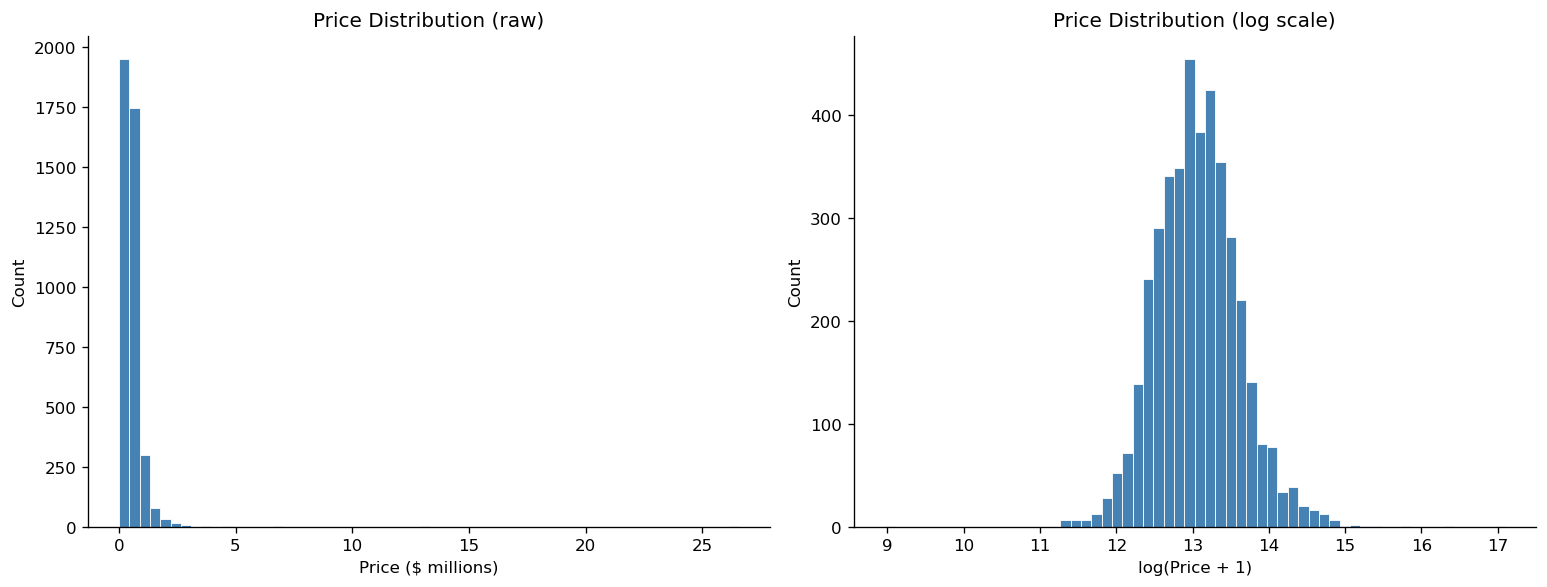

Note: The log-scale view confirms right skew, a few very expensive properties pull the mean upward.


In [5]:
# Visualise the price distribution before cleaning
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_raw['price'] / 1e6, bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Price ($ millions)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution (raw)')

axes[1].hist(np.log1p(df_raw[df_raw['price'] > 0]['price']), bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price Distribution (log scale)')

plt.tight_layout()
plt.show()
print('Note: The log-scale view confirms right skew, a few very expensive properties pull the mean upward.')

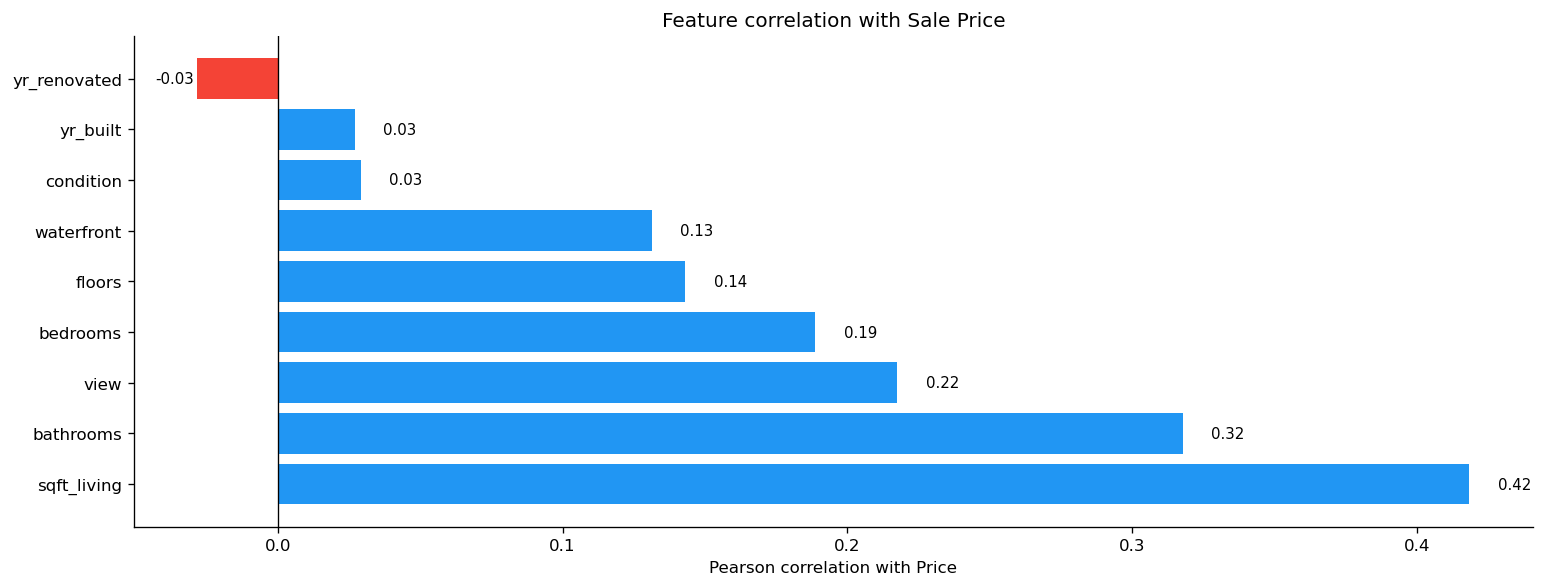

In [6]:
# Correlation heatmap (numeric features vs price)
numeric_cols = ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'floors',
                'condition', 'yr_built', 'yr_renovated', 'view', 'waterfront']
corr = df_raw[numeric_cols].corr()[['price']].drop('price').sort_values('price', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr['price']]
bars = ax.barh(corr.index, corr['price'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with Price')
ax.set_title('Feature correlation with Sale Price')
for bar, val in zip(bars, corr['price']):
    ax.text(val + (0.01 if val >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Data Cleaning & Feature Selection

49 records (1.2% of the dataset) had a sale price of $0, which are almost certainly data entry errors. These were removed before modeling to avoid distorting results.

The condition column contained 545 missing entries, which I filled using the median. I chose the median over the mean because it's less sensitive to outliers, which felt like the right call for a skewed variable like property condition.

In [7]:
df = df_raw.copy()

# Remove zero-price records (data errors)
df = df[df['price'] > 0]
print(f'Removed {len(df_raw) - len(df)} zero-price records. Remaining: {len(df)}')

# Impute missing condition values with median
median_condition = df['condition'].median()
df['condition'] = df['condition'].fillna(median_condition)
print(f'Imputed {df_raw["condition"].isnull().sum()} missing condition values with median ({median_condition})')

print(f'\nFinal dataset: {df.shape[0]} records, {df.shape[1]} columns')

Removed 49 zero-price records. Remaining: 4091
Imputed 545 missing condition values with median (3.0)

Final dataset: 4091 records, 13 columns


The feature set includes everything structural the dataset offers: sqft_living, bedrooms, bathrooms, floors, condition, yr_built, yr_renovated, view and waterfront. The last one, a simple yes/no flag for whether a property is on the waterfront, turns out to matter quite a lot.

Data was split 80/20 into training and test sets. Three models were trained, but importantly, the Decision Tree and Random Forest weren't just run on default settings. Without constraints, tree models will memorise the training data and fall apart on anything new. So both were regularised with max_depth and min_samples_leaf limits to keep them honest. All three models were also evaluated with 5-fold cross-validation, not just a single test split.

In [8]:
# Feature selection, all available structural features including waterfront
FEATURES = [
    'sqft_living',   # interior living area (strongest correlate)
    'bedrooms',
    'bathrooms',
    'floors',
    'condition',
    'yr_built',
    'yr_renovated',
    'view',
    'waterfront',    # binary flag
]

X = df[FEATURES]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')

Training set:  3272 samples
Test set:      819 samples


## 4. Model Training

Three models are trained. The Decision Tree and Random Forest use regularisation hyperparameters (`max_depth`, `min_samples_leaf`) to prevent overfitting, making the comparison fair.

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=6,
        min_samples_leaf=10,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')

    results[name] = {
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'CV R² (mean)': cv_r2.mean(),
        'CV R² (std)': cv_r2.std(),
    }
    predictions[name] = y_pred

results_df = pd.DataFrame(results).T.copy()
for col in ['MAE', 'RMSE']:
    results_df[col] = results_df[col].apply(lambda x: f'${float(x):,.0f}')
for col in ['R²', 'CV R² (mean)', 'CV R² (std)']:
    results_df[col] = results_df[col].apply(lambda x: f'{float(x):.4f}')

print('=== Model Comparison ===')
results_df

=== Model Comparison ===


,R²,MAE,RMSE,CV R² (mean),CV R² (std)
Linear Regression,0.5478,"$160,508","$267,982",0.4721,0.2226
Decision Tree,0.2505,"$183,162","$345,011",0.2815,0.1335
Random Forest,0.3112,"$178,301","$330,757",0.3494,0.1643


Linear Regression came out on top, which might seem surprising, but it makes sense here. With a relatively small and mostly linear feature set, the added complexity of tree-based models doesn't buy much. They can't find structure that isn't there.

The model explains about 55% of the variation in sale prices, with an average prediction error around $160,000. That's reasonable for a structural-features-only model, but it's also a clear signal that price is being driven by things we're not measuring - location above all else.

The cross-validation R² (0.47) is worth noting too. It's lower than the test score (0.55), which means the test split was slightly kind. The CV number is the more honest estimate of how this would perform on genuinely new data.

## 5. Model Evaluation & Diagnostics

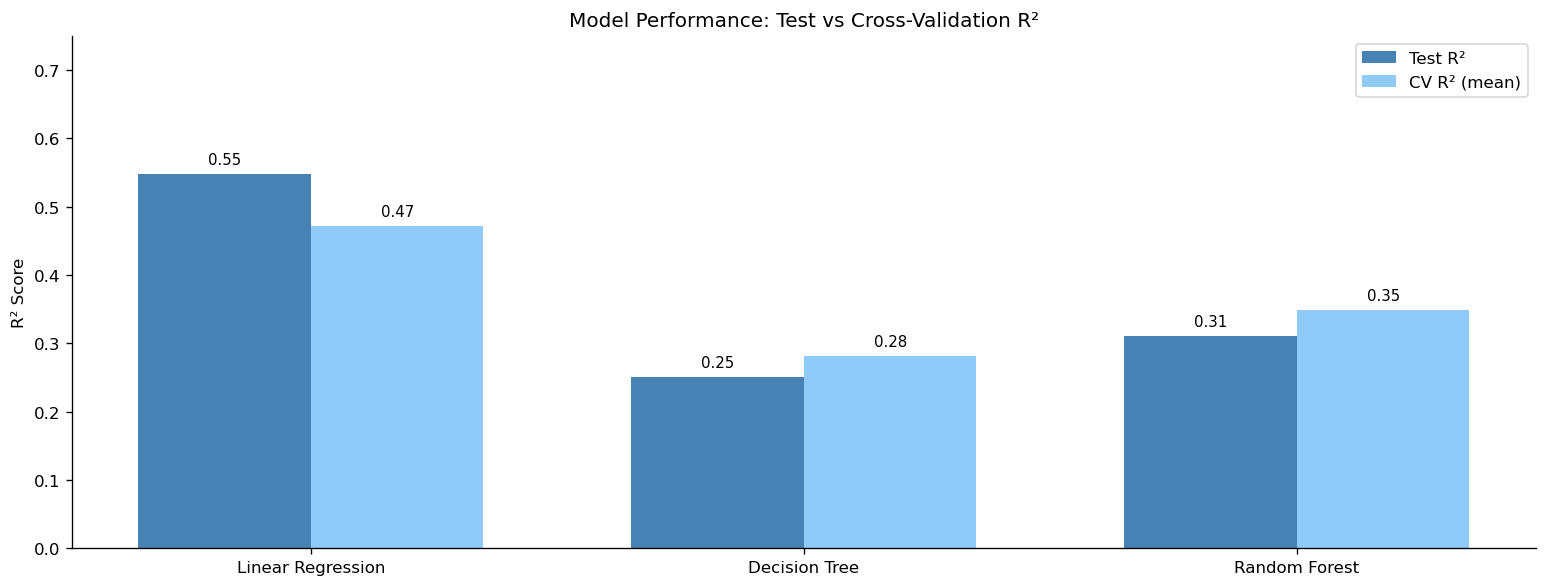

In [10]:
# R² bar chart - Test vs Cross-Validation
r2_values = {name: r2_score(y_test, predictions[name]) for name in models}
cv_means  = {name: results[name]['CV R² (mean)'] for name in models}

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(models))
w = 0.35

bars1 = ax.bar(x - w/2, list(r2_values.values()), w, label='Test R²', color='steelblue')
bars2 = ax.bar(x + w/2, list(cv_means.values()),  w, label='CV R² (mean)', color='#90CAF9')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()))
ax.set_ylabel('R² Score')
ax.set_title('Model Performance: Test vs Cross-Validation R²')
ax.set_ylim(0, 0.75)
ax.legend()
plt.tight_layout()
plt.show()

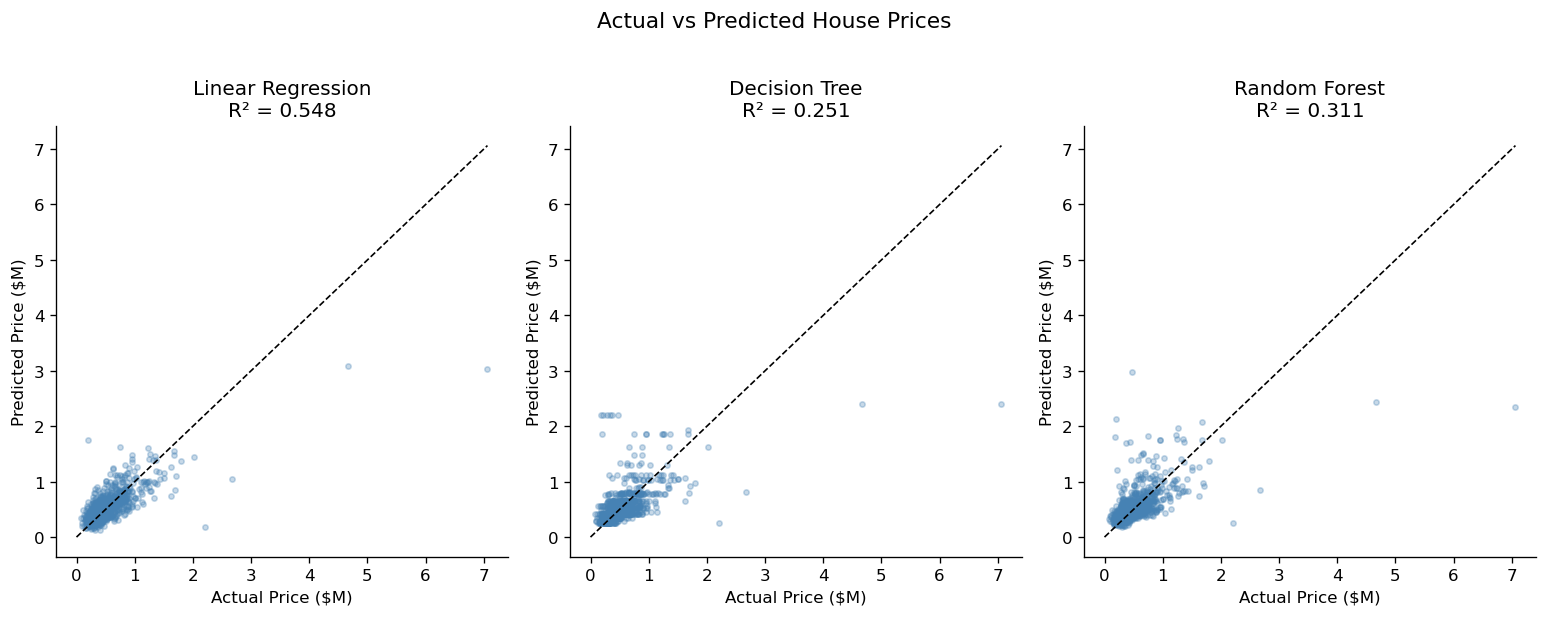

In [11]:
# Actual vs Predicted - all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.3, s=10, color='steelblue')
    lims = [0, max(y_test.max(), y_pred.max()) / 1e6]
    ax.plot(lims, lims, '--', color='black', linewidth=1)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.3f}')
    ax.set_xlabel('Actual Price ($M)')
    ax.set_ylabel('Predicted Price ($M)')

plt.suptitle('Actual vs Predicted House Prices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Looking at the residuals, there's a clear fan-shaped pattern, errors stay small for cheaper homes but blow out for expensive ones. This is heteroscedasticity and it shows up in the Q-Q plot too, where the tails deviate from the normal line. In plain terms: the model is fairly reliable in the middle of the market, but loses confidence at the high end where premium factors like views, neighbourhood prestige, and lot quality start dominating the price.

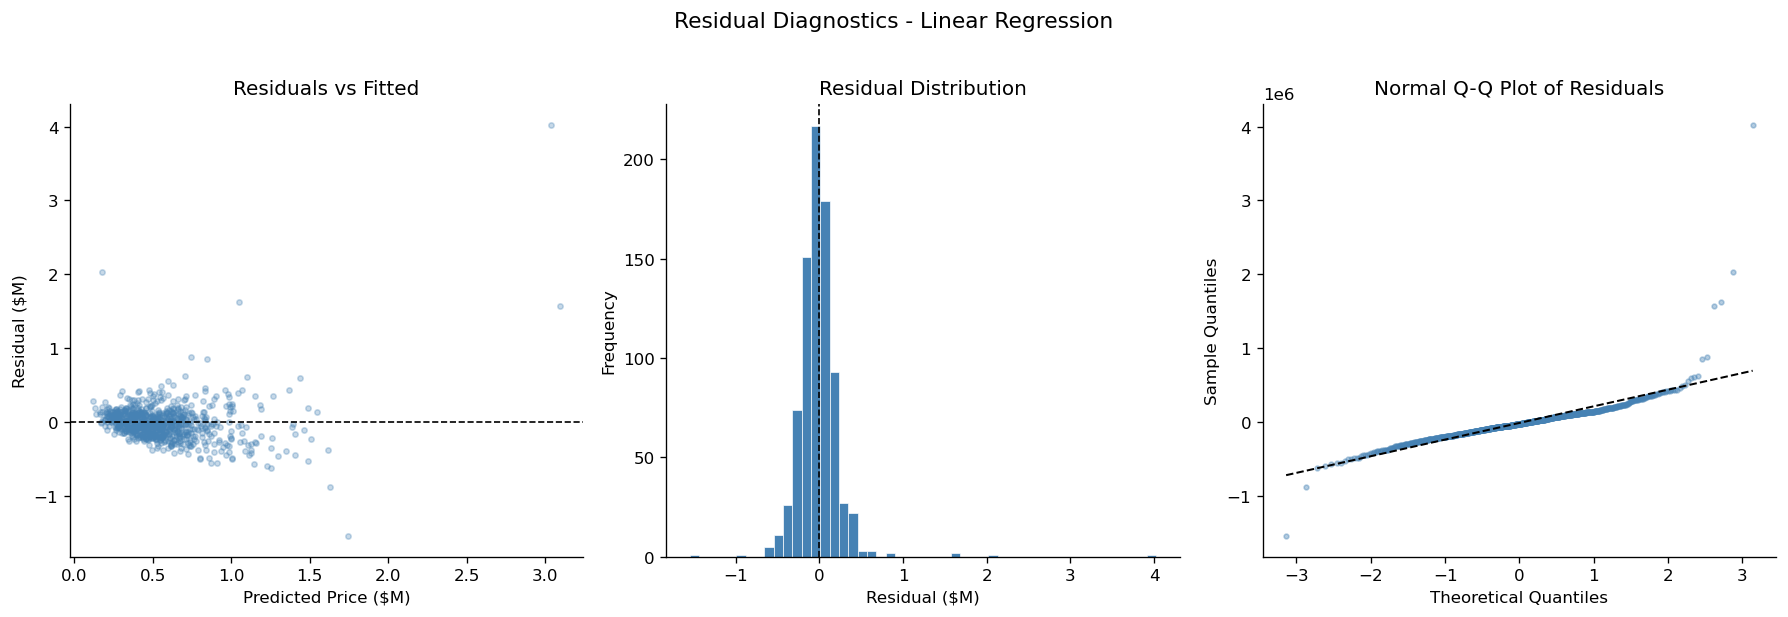

Residual mean: $-15,700
Residual std:  $267,685

The fan-shaped pattern in Residuals vs Fitted indicates heteroscedasticity:
errors grow with predicted price, which is common in real estate data.


In [12]:
# Residual diagnostics for the best model (Linear Regression)
best_name   = 'Linear Regression'
y_pred_best = predictions[best_name]
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred_best / 1e6, residuals / 1e6, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price ($M)')
axes[0].set_ylabel('Residual ($M)')
axes[0].set_title('Residuals vs Fitted')

# Histogram of residuals
axes[1].hist(residuals / 1e6, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual ($M)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# Normal Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, s=8, alpha=0.4, color='steelblue')
line_x = np.array([osm.min(), osm.max()])
axes[2].plot(line_x, slope * line_x + intercept, color='black', linewidth=1.2, linestyle='--')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title('Normal Q-Q Plot of Residuals')

plt.suptitle(f'Residual Diagnostics - {best_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Residual mean: ${residuals.mean():,.0f}')
print(f'Residual std:  ${residuals.std():,.0f}')
print()
print('The fan-shaped pattern in Residuals vs Fitted indicates heteroscedasticity:')
print('errors grow with predicted price, which is common in real estate data.')

## 6. Feature Importance

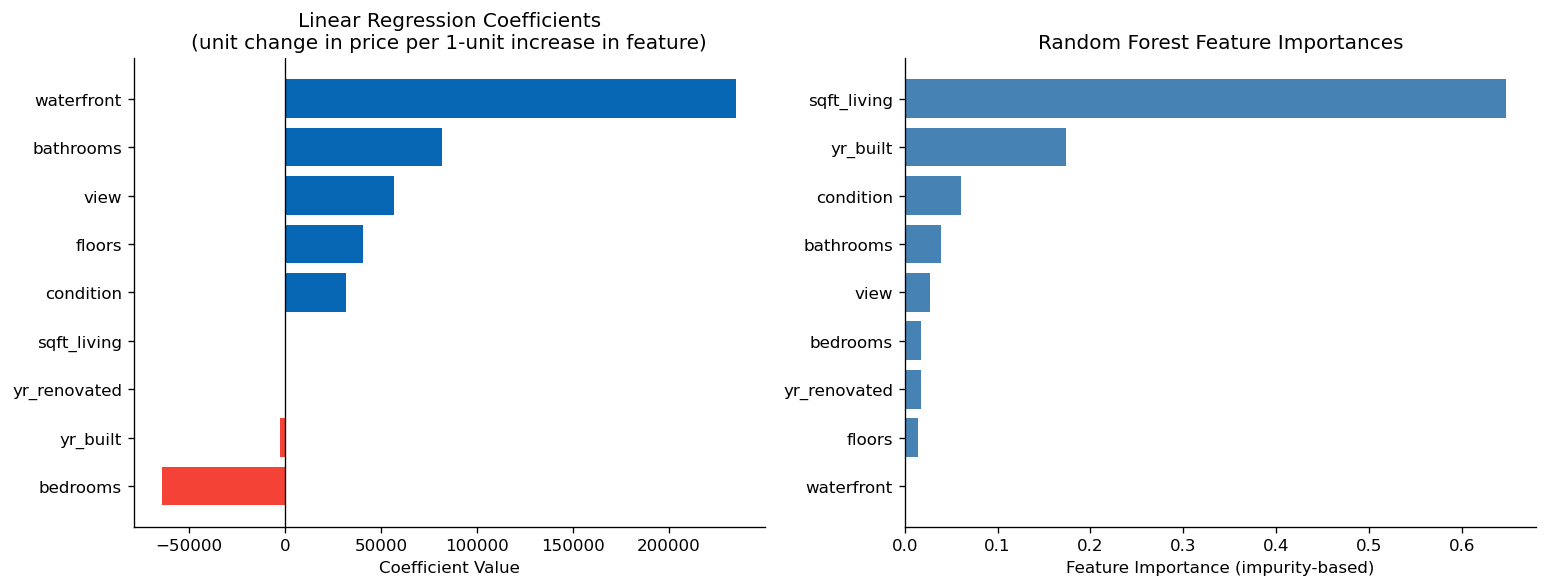

Note: LR coefficients are scale-dependent, features with larger value ranges
(like sqft_living) appear smaller than binary features (like waterfront).


In [13]:
lr_model = models['Linear Regression']
rf_model = models['Random Forest']

coefs  = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr_model.coef_}).sort_values('Coefficient', ascending=True)
rf_imp = pd.DataFrame({'Feature': FEATURES, 'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LR coefficients
colors_coef = ['#F44336' if c < 0 else "#0867B5" for c in coefs['Coefficient']]
axes[0].barh(coefs['Feature'], coefs['Coefficient'], color=colors_coef)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Linear Regression Coefficients\n(unit change in price per 1-unit increase in feature)')

# RF feature importances
axes[1].barh(rf_imp['Feature'], rf_imp['Importance'], color='steelblue')
axes[1].set_xlabel('Feature Importance (impurity-based)')
axes[1].set_title('Random Forest Feature Importances')

plt.tight_layout()
plt.show()

print('Note: LR coefficients are scale-dependent, features with larger value ranges')
print('(like sqft_living) appear smaller than binary features (like waterfront).')

## 7. Summary & Conclusions

| Model | Test R² | CV R² | MAE | RMSE |
|---|---|---|---|---|
| Linear Regression | 0.55 | 0.47 | $160,508 | $267,982 |
| Decision Tree (tuned) | 0.25 | 0.28 | $183,162 | $345,011 |
| Random Forest (tuned) | 0.31 | 0.35 | $178,301 | $330,757 |

**Linear Regression is the best-performing model** on this feature set, not because tree-based models are inherently worse, but because the available features are too few and too linear for tree models to find meaningful splits beyond what a linear fit already captures. Give a Random Forest rich location data and it would likely pull ahead, but it's a good illustration of why model choice should follow the data, not the other way around.

On predicting price from structure alone: it works, up to a point. Fifty-five percent of price variance is explainable from physical features, which is genuinely useful as a baseline. But a $160,000 average error on a median price around $460,000 is a honest reminder that a house is more than its square footage.

On the residuals: the heteroscedasticity pattern is the most useful diagnostic finding. It points directly at what's missing: the model doesn't know anything about where the house is, and for expensive properties that matters enormously. The diagnostics don't just show that the model has limits, they show where and why.

Key takeaways:

1. **`sqft_living` is the dominant predictor** - confirmed by both LR coefficients and RF feature importances.
2. **Including `waterfront` improved R² from ~0.39 to ~0.55** - a meaningful gain from a single binary feature that was previously excluded.
3. **Heteroscedasticity is present**: prediction errors grow with property value, suggesting that expensive homes are driven by factors not in this dataset (location, neighbourhood quality, lot premium).
4. **Cross-validation R² is lower than test R²**, which means the test split was slightly favourable. CV R² gives a more realistic estimate of real-world performance.
5. **49 zero-price records were removed** as data errors - their inclusion distorted earlier baseline results.

The biggest lesson was how much data quality and feature selection matter before any modeling begins. Cleaning the zero-price records and adding waterfront (one binary column) pushed R² from 0.39 to 0.55. No amount of model tuning would have achieved that.

Fair comparison was another thing that required care. Tree models with no constraints will overfit badly and look terrible against a linear model on test data, not because they're worse, but because the comparison isn't set up properly. Getting that right meant applying regularisation and cross-validation consistently across all three.

And finally, the residual diagnostics turned out to be more informative than the headline metrics. R² tells you how well the model fits. Residual plots tell you how it's failing, and that's usually the more actionable insight.

## Challenges

The trickiest part wasn't the modeling, it was the data. Zero-price records don't show up in a missing value check. You only spot them if you think to ask whether the values make sense in the real world, not just whether they're present. That kind of domain-aware inspection is easy to skip and expensive to miss.

The model comparison also required some thought. An unconstrained Decision Tree can score R² = -1.97 on test data, which looks like a damning result until you realise it just memorised the training set. Understanding why that happens, and how to fix it, was more valuable than the final numbers.